In [18]:
import numpy as np
import pandas as pd
import time

In [19]:
df = pd.read_csv('/home/karan/DL2.0/Datasets/Social_Network_Ads.csv')

In [20]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [21]:
df = df[['Age','EstimatedSalary','Purchased']]

In [22]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [23]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [24]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [26]:
X_scaled.shape

(400, 2)

In [27]:
#from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [28]:
#X_train.shape

In [29]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [30]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/home/karan/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=500,batch_size=400,validation_split=0.2)
#print(time.time() - start)

Epoch 1/500


2026-05-30 11:22:09.525809: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_290', 4 bytes spill stores, 4 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7094 - loss: 0.6015 - val_accuracy: 0.4375 - val_loss: 0.7096
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7188 - loss: 0.5936 - val_accuracy: 0.4625 - val_loss: 0.7089
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7188 - loss: 0.5879 - val_accuracy: 0.4625 - val_loss: 0.7083
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7188 - loss: 0.5832 - val_accuracy: 0.4625 - val_loss: 0.7076
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7188 - loss: 0.5790 - val_accuracy: 0.4750 - val_loss: 0.7070
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7188 - loss: 0.5752 - val_accuracy: 0.4750 - val_loss: 0.7064
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7188 - loss: 0.5716 - val_accuracy: 0.4750 - val_loss: 0.7058
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7188 - loss: 0.5683 - val_accuracy: 0.4750 - val_loss: 0.7052
Epoch

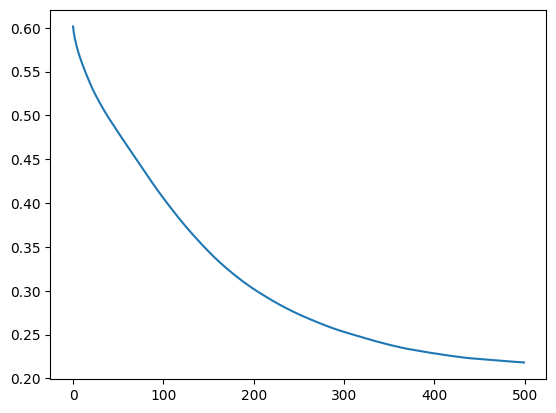

In [33]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [34]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [35]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)
#print(time.time() - start)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7125 - loss: 0.6786 - val_accuracy: 0.5250 - val_loss: 0.7383
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7188 - loss: 0.6616 - val_accuracy: 0.5500 - val_loss: 0.7321
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7250 - loss: 0.6509 - val_accuracy: 0.5625 - val_loss: 0.7247
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7312 - loss: 0.6419 - val_accuracy: 0.5375 - val_loss: 0.7212
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7250 - loss: 0.6342 - val_accuracy: 0.5625 - val_loss: 0.7171
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7281 - loss: 0.6272 - val_accuracy: 0.5625 - val_loss: 0.7136
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7250 - loss: 0.6207 - val_accuracy: 0.5250 - val_loss: 0.7101
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7312 - loss: 0.6145 - val_accuracy: 0.5500 - val_loss: 0.7058
Ep

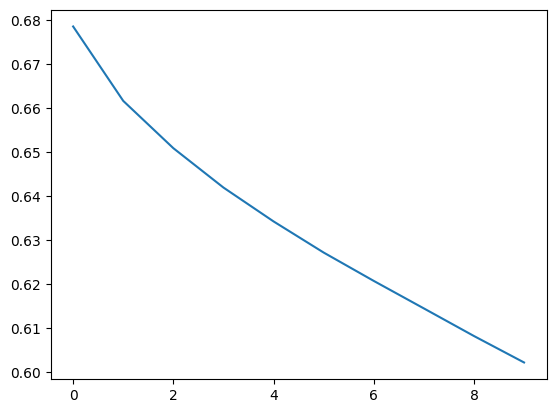

In [36]:
plt.plot(history.history['loss'])